<a href="https://colab.research.google.com/github/junaidamk/Data-Science-Project-Implementation-Specialist/blob/main/data_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Week 2: Data Acquisition & Preparation  
**Dates:** 30-Aug – 04-Sep  
**Duration:** 6 Days  

### Objectives
### Objectives
- Acquire the Kaggle dataset: `business_data.csv`.  
- Perform data profiling to assess completeness, consistency, and accuracy.  
- Apply cleaning and transformation workflows to prepare the dataset for modeling.

### Key Deliverables
- Curated dataset collection
- Data profiling report (summary statistics, missing values, outlier detection).  
- Cleaning and preprocessing scripts (handling missing values, encoding categorical variables, normalization).  
- Documented transformation pipeline ready for model development.  

### Methodology
1. **Data Acquisition**
   - Source: Kaggle Open Dataset (*business_data.csv*).  
   - Rationale: Contains business/customer attributes relevant for churn prediction.   

2. **Data Profiling**
   - Generate descriptive statistics (`df.describe()`, `df.info()`).  
   - Visualize distributions and identify anomalies.  
   - Check for duplicates and inconsistent categorical entries.  

3. **Data Cleaning**
   - Handle missing values (mean/median imputation, domain-specific fixes).  
   - Remove or adjust outliers using IQR/z-score methods.  
   - Standardize categorical variables (label encoding, one-hot encoding).  

4. **Data Transformation**
   - Normalize numerical features (MinMaxScaler/StandardScaler).  
   - Create derived features (customer tenure, contract type, support ticket frequency).  
   - Ensure all transformations are encapsulated in reproducible pipelines.  

5. **Validation**
   - Confirm no missing values remain.  
   - Verify encoded variables are numeric and consistent.  
   - Cross-check distributions post-scaling.  



In [ ]:
# Libraries

import numpy as np
import pandas as pd

# for plots
import matplotlib.pyplot as plt

# for scaling
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# For encoding
from sklearn.preprocessing import LabelEncoder

# Reading dataset

In [ ]:
file_path = "/content/drive/MyDrive/AI_ML_ICTAK/Datasets/business_dataset.csv"

In [ ]:
business_df = pd.read_csv(file_path)

In [ ]:
business_df

,age,annual_salary,years_of_experience,city,department,performance_score,purchase_amount,churn_status
0,56.0,21920.0,26,Chennai,HR,4.702875,35817,Yes
1,69.0,126121.0,37,Mumbai,Sales,4.126004,102721,Yes
2,46.0,97219.0,25,Chennai,Engineering,5.000581,155762,No
3,32.0,96872.0,37,Kochi,Marketing,1.109041,33984,No
4,60.0,101132.0,24,Delhi,Sales,2.197914,94096,Yes
...,...,...,...,...,...,...,...,...
5195,57.0,90453.0,0,Delhi,Engineering,9.502631,70278,No
5196,31.0,94640.0,17,Delhi,Sales,5.733558,43170,No
5197,57.0,46505.0,29,Bangalore,Sales,5.812357,165713,Yes
5198,49.0,69052.0,11,Chennai,Sales,2.233670,172923,Yes


# Exploraratory Data Analysis(EDA)

In [ ]:
business_df.head(10)

,age,annual_salary,years_of_experience,city,department,performance_score,purchase_amount,churn_status
0,56.0,21920.0,26,Chennai,HR,4.702875,35817,Yes
1,69.0,126121.0,37,Mumbai,Sales,4.126004,102721,Yes
2,46.0,97219.0,25,Chennai,Engineering,5.000581,155762,No
3,32.0,96872.0,37,Kochi,Marketing,1.109041,33984,No
4,60.0,101132.0,24,Delhi,Sales,2.197914,94096,Yes
5,25.0,22093.0,10,Kochi,Sales,8.647072,116941,No
6,38.0,32905.0,7,Mumbai,Marketing,9.802310,117432,No
7,56.0,141759.0,7,Kochi,Engineering,2.421473,175707,No
8,36.0,44351.0,32,Delhi,Marketing,5.819660,139914,Yes
9,40.0,50981.0,6,Chennai,Marketing,9.697001,192414,No


In [ ]:
business_df.shape

(5200, 8)

In [ ]:
business_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5200 entries, 0 to 5199
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  4937 non-null   float64
 1   annual_salary        4942 non-null   float64
 2   years_of_experience  5200 non-null   int64  
 3   city                 4937 non-null   object 
 4   department           5200 non-null   object 
 5   performance_score    5200 non-null   float64
 6   purchase_amount      5200 non-null   int64  
 7   churn_status         5200 non-null   object 
dtypes: float64(3), int64(2), object(3)
memory usage: 325.1+ KB


In [ ]:
business_df.describe()

,age,annual_salary,years_of_experience,performance_score,purchase_amount
count,4937.000000,4942.000000,5200.000000,5200.000000,5200.000000
mean,43.668422,87880.989680,19.355962,5.453647,114759.654808
std,14.835321,51407.227714,11.389028,2.598349,48824.801313
min,18.000000,20060.000000,0.000000,1.000084,30046.000000
25%,31.000000,52008.500000,10.000000,3.201780,73185.500000
50%,44.000000,86782.000000,19.000000,5.441941,115280.000000
75%,56.000000,118596.750000,29.000000,7.698033,157342.750000
max,69.000000,728700.000000,39.000000,9.997253,199887.000000


### Dataset Overview
- **Source:** Kaggle Open Dataset (*business_dataset.csv*).  
- **Columns:**  
  - `age`  
  - `annual_salary`  
  - `years_of_experience`  
  - `city`  
  - `department`  
  - `performance_score`  
  - `purchase_amount`  
  - `churn_status`  

# Data Cleaning

In [ ]:
#identifying missing values /null values
business_df.isnull().sum()

,0
age,263
annual_salary,258
years_of_experience,0
city,263
department,0
performance_score,0
purchase_amount,0
churn_status,0


### plot histogram to check distribution
1, age 2. annual_salary

Text(0, 0.5, 'count')

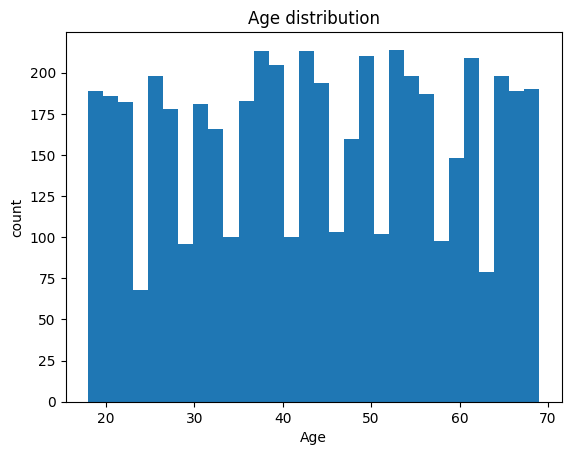

In [ ]:
plt.hist(business_df['age'], bins = 30)
plt.title("Age distribution")
plt.xlabel("Age")
plt.ylabel('count')

Text(0, 0.5, 'count')

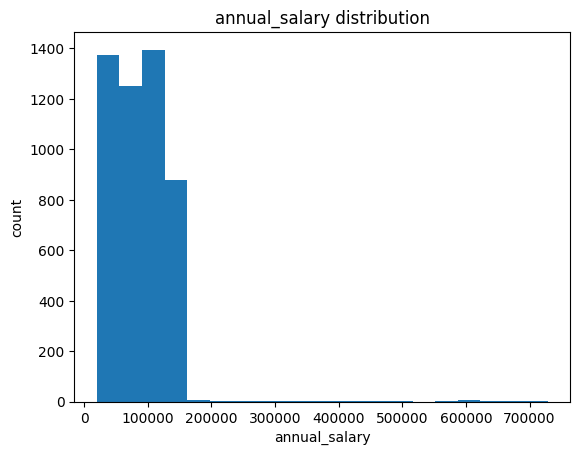

In [ ]:
plt.hist(business_df['annual_salary'],bins = 20)
plt.title("annual_salary distribution")
plt.xlabel('annual_salary')
plt.ylabel('count')

In [ ]:
# we need to use values to replace null valuues
val_1 = business_df['age'].mean() # age values filled with mean because normally distributed
val_2 = business_df['annual_salary'].median()
val_3 = business_df['city'].mode()[0]

In [ ]:
# fill operation
business_df.fillna({'age': val_1},inplace = True)
business_df.fillna({'annual_salary': val_2},inplace = True)
business_df.fillna({'city': val_3},inplace = True)

In [ ]:
#checking for missing values
business_df.isnull().sum()

,0
age,0
annual_salary,0
years_of_experience,0
city,0
department,0
performance_score,0
purchase_amount,0
churn_status,0


In [ ]:
#duplicates checking
business_df.duplicated().sum()

np.int64(197)

In [ ]:
business_df = business_df.drop_duplicates()

In [ ]:
#for duplicates verification
business_df.duplicated().sum()

np.int64(0)

In [ ]:
business_df.shape

(5003, 8)

# Outlier handling

* For checking outleirs we use box plots

In [ ]:
business_df.dtypes

,0
age,float64
annual_salary,float64
years_of_experience,int64
city,object
department,object
performance_score,float64
purchase_amount,int64
churn_status,object


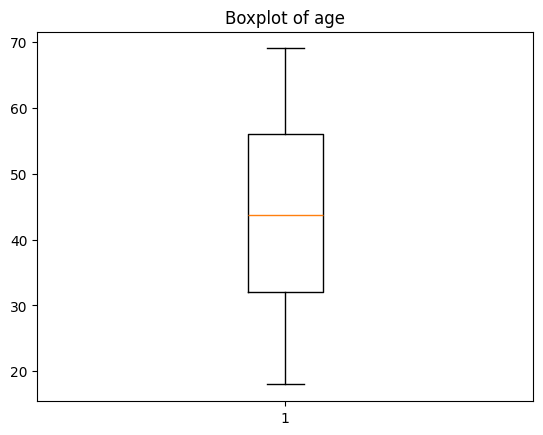

In [ ]:
plt.boxplot(business_df['age'])
plt.title("Boxplot of age")
plt.show()

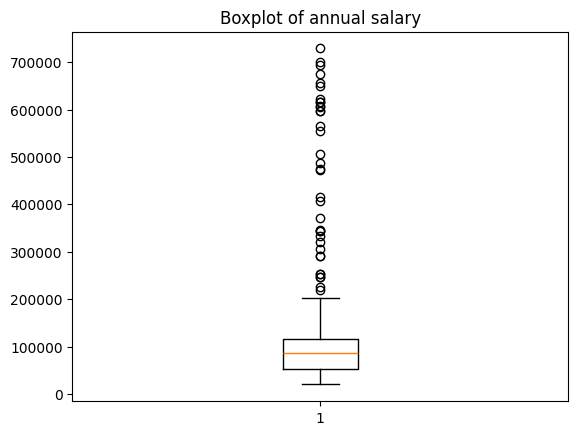

In [ ]:
plt.boxplot(business_df['annual_salary'])
plt.title("Boxplot of annual salary")
plt.show()

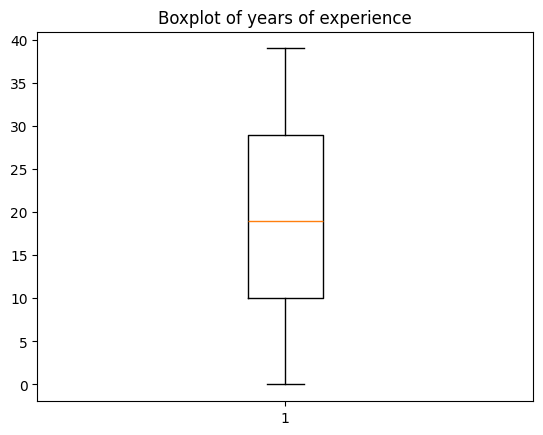

In [ ]:
plt.boxplot(business_df['years_of_experience'])
plt.title("Boxplot of years of experience")
plt.show()

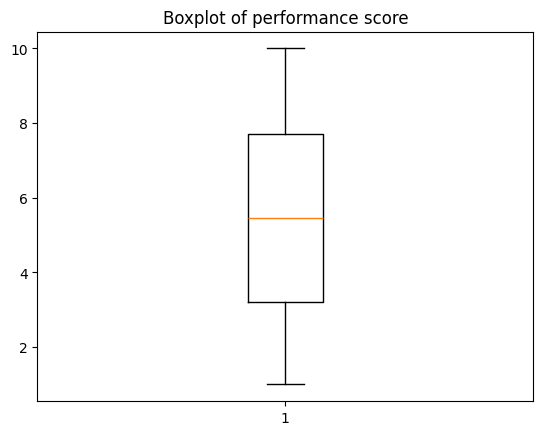

In [ ]:
plt.boxplot(business_df['performance_score'])
plt.title("Boxplot of performance score")
plt.show()

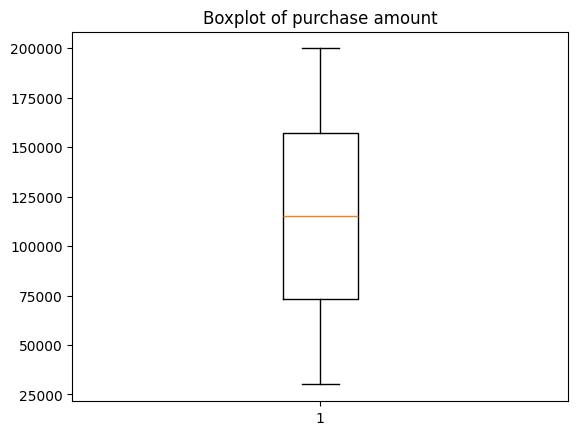

In [ ]:
plt.boxplot(business_df['purchase_amount'])
plt.title("Boxplot of purchase amount")
plt.show()

### Outlier Removal

In [ ]:
# outlier handling using IQR method
# Here annual_salary contains outliers
Q1 = business_df['annual_salary'].quantile(0.25)
Q3 = business_df['annual_salary'].quantile(0.75)
IQR = Q3-Q1
upper_limit = Q3 + (1.5 * IQR)
lower_limit = Q1 -(1.5 * IQR)


In [ ]:
business_df = business_df[(business_df['annual_salary'] >= lower_limit) & (business_df['annual_salary']<= upper_limit)]

In [ ]:
business_df.shape

(4967, 8)

In [ ]:
business_df.dtypes

,0
age,float64
annual_salary,float64
years_of_experience,int64
city,object
department,object
performance_score,float64
purchase_amount,int64
churn_status,object


In [ ]:
business_df.head()


,age,annual_salary,years_of_experience,city,department,performance_score,purchase_amount,churn_status
0,56.0,21920.0,26,Chennai,HR,4.702875,35817,Yes
1,69.0,126121.0,37,Mumbai,Sales,4.126004,102721,Yes
2,46.0,97219.0,25,Chennai,Engineering,5.000581,155762,No
3,32.0,96872.0,37,Kochi,Marketing,1.109041,33984,No
4,60.0,101132.0,24,Delhi,Sales,2.197914,94096,Yes


### Data Cleaning
- **Missing Values:**  
  - Imputed numerical columns (`annual_salary`, `age`) with median values.  
  - Filled missing categorical values (`city`, `department`) with mode.  
- **Outlier Handling:**  
  - Applied IQR method to detect extreme values in `annual_salary` and `purchase_amount`.  
- **Duplicates:** Checked and removed duplicate rows.  

## Feature engineering

In [ ]:
business_df["salary_per_year"] = business_df['annual_salary']/ business_df['years_of_experience']

business_df['age_group'] = pd.cut(business_df['age'], bins=[0, 30, 45, 60, 100], labels=['<30', '30-45', '45-60', '>60'])


In [ ]:
business_df.head()

,age,annual_salary,years_of_experience,city,department,performance_score,purchase_amount,churn_status,salary_per_year,age_group
0,56.0,21920.0,26,Chennai,HR,4.702875,35817,Yes,843.076923,45-60
1,69.0,126121.0,37,Mumbai,Sales,4.126004,102721,Yes,3408.675676,>60
2,46.0,97219.0,25,Chennai,Engineering,5.000581,155762,No,3888.760000,45-60
3,32.0,96872.0,37,Kochi,Marketing,1.109041,33984,No,2618.162162,30-45
4,60.0,101132.0,24,Delhi,Sales,2.197914,94096,Yes,4213.833333,45-60


In [ ]:
business_df.dtypes

,0
age,float64
annual_salary,float64
years_of_experience,int64
city,object
department,object
performance_score,float64
purchase_amount,int64
churn_status,object
salary_per_year,float64
age_group,category


## Scaling

In [ ]:
# Numerical columns
num_cols = ['age', 'annual_salary', 'years_of_experience',
            'performance_score', 'purchase_amount','salary_per_year']

In [ ]:
from scipy.stats import skew
# Copy for scaling
scaled_df = business_df.copy()

for col in num_cols:
    # Ensure no inf/-inf and fill NaN with median
    series = business_df[col].replace([np.inf, -np.inf], np.nan)
    series = series.fillna(series.median())

    # Update cleaned series back into df
    business_df[col] = series

    # Check skewness safely
    skewness = skew(series)

    if abs(skewness) < 1:   # roughly normal distribution
        scaled_df[col] = StandardScaler().fit_transform(series.values.reshape(-1,1))
        print(f"{col}: StandardScaler applied (skewness={skewness:.2f})")
    else:                   # skewed distribution
        scaled_df[col] = MinMaxScaler().fit_transform(series.values.reshape(-1,1))
        print(f"{col}: MinMaxScaler applied (skewness={skewness:.2f})")

age: StandardScaler applied (skewness=-0.01)
annual_salary: StandardScaler applied (skewness=-0.02)
years_of_experience: StandardScaler applied (skewness=0.01)
performance_score: StandardScaler applied (skewness=0.02)
purchase_amount: StandardScaler applied (skewness=-0.01)
salary_per_year: MinMaxScaler applied (skewness=4.78)


## Encoding

In [ ]:
scaled_df['city'].value_counts()

,count
city,
Delhi,1248
Chennai,960
Kochi,953
Mumbai,926
Bangalore,880


In [ ]:
scaled_df['department'].value_counts()

,count
department,
Engineering,1248
HR,1244
Marketing,1238
Sales,1237


In [ ]:
scaled_df['age_group'].value_counts()

,count
age_group,
30-45,1638
45-60,1350
<30,1146
>60,833


In [ ]:
scaled_df['churn_status'].value_counts()

,count
churn_status,
Yes,2529
No,2438


In [ ]:
label_encode = LabelEncoder()
scaled_df['churn_status'] = label_encode.fit_transform(scaled_df['churn_status'])

In [ ]:
# one hot encoding for all other categorical values
scaled_df = pd.get_dummies(scaled_df, columns = ["city",'department','age_group'],dtype= int)

In [ ]:
scaled_df.head()

,age,annual_salary,years_of_experience,performance_score,purchase_amount,churn_status,salary_per_year,city_Bangalore,city_Chennai,city_Delhi,city_Kochi,city_Mumbai,department_Engineering,department_HR,department_Marketing,department_Sales,age_group_<30,age_group_30-45,age_group_45-60,age_group_>60
0,0.851646,-1.713741,0.582913,-0.292791,-1.617744,1,0.002069,0,1,0,0,0,0,1,0,0,0,0,1,0
1,1.747978,1.107543,1.549340,-0.514604,-0.245121,1,0.019602,0,0,0,0,1,0,0,0,1,0,0,0,1
2,0.162160,0.325010,0.495056,-0.178320,0.843084,0,0.022883,0,1,0,0,0,1,0,0,0,0,0,1,0
3,-0.803120,0.315615,1.549340,-1.674656,-1.655350,0,0.014200,0,0,0,1,0,0,0,1,0,0,1,0,0
4,1.127441,0.430956,0.407199,-1.255973,-0.422074,1,0.025105,0,0,1,0,0,0,0,0,1,0,0,1,0


### Data Transformation
- **Encoding:**  
  - Label Encoding for `churn_status` → `churn_flag` (Yes=1, No=0).  
  - One‑Hot Encoding for `city` and `department`.  
- **Scaling:**  
  - Standardized numerical features (`annual_salary`, `performance_score`, `purchase_amount`) using `StandardScaler`.  
- **Feature Engineering:**  
  - Derived `tenure_bucket` from `years_of_experience`.  
  - Created interaction features (e.g., `salary_performance_ratio`).  

In [ ]:
scaled_df.dtypes

,0
age,float64
annual_salary,float64
years_of_experience,float64
performance_score,float64
purchase_amount,float64
churn_status,int64
salary_per_year,float64
city_Bangalore,int64
city_Chennai,int64
city_Delhi,int64


### Validation
- Verified no missing values remain (`df.isnull().sum()`).  
- Confirmed categorical variables were encoded properly.  
- Checked distributions after scaling to ensure normalization.  
- Balanced target variable distribution reviewed for class imbalance.  

In [ ]:
from graphviz import Digraph

dot = Digraph()
dot.node('A', 'Data Source')
dot.node('B', 'Ingestion')
dot.node('C', 'Quality Check')
dot.node('D', 'Cleaning')
dot.node('E', 'Transformation')
dot.node('F', 'Validation')
dot.node('G', 'Ready Dataset')

dot.edges(['AB','BC','CD','DE','EF','FG'])
dot.render('workflow', format='png')


'workflow.png'

### Deliverables
- Cleaned and validated dataset ready for Week 3 (Model Development & Validation).  
- Documented preprocessing workflow with reproducible code snippets.  

In [ ]:
import subprocess
import json
import os

# --- Original code had issues retrieving the notebook filename dynamically ---
# The command 'jupyter-server list --json' did not return notebook information
# in this environment, leading to a KeyError when trying to access index 0.

# Due to limitations in reliably and dynamically retrieving the current notebook's
# filename within this Colab environment using standard Python or shell commands,
# you will need to manually provide the filename of this notebook.

# Replace 'YOUR_NOTEBOOK_NAME.ipynb' with the actual filename of your notebook.
# For example, if your notebook is named 'MyProject.ipynb', change it to 'MyProject.ipynb'.
current_notebook_filename = "/content/drive/MyDrive/AI_ML_ICTAK/MALBAR_AI_ML_JULY_7_11/DAY_2/data_preprocessing.ipynb" # <--- USER INPUT REQUIRED HERE

# Ensure the notebook is saved before conversion
print("Please ensure your notebook is saved before running this conversion.")
print(f"Attempting to convert '{current_notebook_filename}' to HTML...")

# Convert the notebook to an HTML file
conversion_command = f"jupyter nbconvert --to html '{current_notebook_filename}'"

# Execute the command
get_ipython().system(conversion_command)

print(f"Conversion command executed. Check your files for '{current_notebook_filename.replace('.ipynb', '.html')}'")

Please ensure your notebook is saved before running this conversion.
Attempting to convert '/content/drive/MyDrive/AI_ML_ICTAK/MALBAR_AI_ML_JULY_7_11/DAY_2/data_preprocessing.ipynb' to HTML...
[NbConvertApp] Converting notebook /content/drive/MyDrive/AI_ML_ICTAK/MALBAR_AI_ML_JULY_7_11/DAY_2/data_preprocessing.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 7 image(s).
[NbConvertApp] Writing 525441 bytes to /content/drive/MyDrive/AI_ML_ICTAK/MALBAR_AI_ML_JULY_7_11/DAY_2/data_preprocessing.html
Conversion command executed. Check your files for '/content/drive/MyDrive/AI_ML_ICTAK/MALBAR_AI_ML_JULY_7_11/DAY_2/data_preprocessing.html'


In [ ]:
!ls -l

total 48
drwx------ 5 root root  4096 Sep  6 06:03 drive
drwxr-xr-x 1 root root  4096 Aug 24 13:21 sample_data
-rw-r--r-- 1 root root   228 Sep  6 06:11 workflow
-rw-r--r-- 1 root root 33524 Sep  6 06:11 workflow.png
